# **JOBLENS - D.A.P.**
- Colab: https://colab.research.google.com/drive/1bWZlwvCedKpPbkBdgZsOLGgjVY1TJa8l?usp=sharing

# SECTION 1: SETUP AND DEPENDENCIES

In [1]:
import subprocess
import pathlib

subprocess.run(["pip", "install", "python-jobspy", "--no-deps", "--quiet"], check=False)
subprocess.run([
    "pip", "install",
    "requests", "tls-client", "beautifulsoup4",
    "markdownify", "regex", "currency-converter",
    "--quiet"
], check=False)

requirements_path = pathlib.Path("../requirements.txt")

if requirements_path.exists():
    packages = [
        line.strip()
        for line in requirements_path.read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not any(pkg in line.lower() for pkg in ["numpy", "pandas", "jobspy"])
    ]
else:
    packages = [
        "scikit-learn",
        "sentence-transformers",
        "keybert",
        "nltk",
        "plotly",
        "wordcloud",
        "matplotlib",
    ]

for package in packages:
    subprocess.run(["pip", "install", package, "--quiet"], check=False)

print("All packages installed.")

import numpy as np
import pandas as pd
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")

All packages installed.
numpy: 2.0.2
pandas: 2.2.2


In [2]:
import json
import os
import re
import time
import warnings
from collections import Counter
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("All imports successful.")

All imports successful.


# SECTION 2: DATA SCRAPING

In [3]:
from jobspy import scrape_jobs
from datetime import datetime, timedelta

job_query = input("Job category (ex: data analyst, software engineer): ").strip()
location_query = input("Location (ex: Surabaya, Jakarta, empty = Indonesia): ").strip() or "Indonesia"

print(f"\nScraping LinkedIn jobs for: '{job_query}' di '{location_query}'...")

all_dfs = []
try:
    tmp = scrape_jobs(
        site_name=["linkedin"],
        search_term=job_query,
        location=location_query,
        results_wanted=500,
        hours_old=8760,
        linkedin_fetch_description=True,
    )
    if len(tmp) > 0:
        tmp["search_query_input"] = job_query
        all_dfs.append(tmp)
        print(f"Berhasil scrape {len(tmp)} jobs.")
except Exception as e:
    print(f"Scraping gagal: {e}")

if not all_dfs:
    raise ValueError("Tidak ada data yang berhasil di-scrape. Coba query atau lokasi lain.")

df_raw = pd.concat(all_dfs, ignore_index=True)
df_raw = df_raw.drop_duplicates(subset=["description"]).copy()

df_raw["date_posted"] = pd.to_datetime(df_raw["date_posted"], errors="coerce")
cutoff = datetime.now() - timedelta(days=365)
df_raw = df_raw[df_raw["date_posted"] >= cutoff].copy()

df_raw = df_raw.rename(columns={
    "title": "job_title",
    "company": "company_name",
    "date_posted": "posted_date",
}, errors="ignore")

df_raw["data_source"] = f"linkedin_realtime_{job_query.replace(' ', '_')}"

standard_cols = ["job_title", "company_name", "location", "description", "posted_date", "engagement_count", "data_source"]
for col in standard_cols:
    if col not in df_raw.columns:
        df_raw[col] = None

df_jobs = df_raw.copy()
df_jobs = df_jobs[df_jobs["description"].notna() & (df_jobs["description"].astype(str).str.strip() != "")]
df_jobs = df_jobs.reset_index(drop=True)

print(f"\ndf_jobs final shape: {df_jobs.shape}")
print(df_jobs["data_source"].value_counts())
print(f"Rentang tanggal: {df_jobs['posted_date'].min()} s/d {df_jobs['posted_date'].max()}")

Job category (ex: data analyst, software engineer): Data
Location (ex: Surabaya, Jakarta, empty = Indonesia): Indonesia

Scraping LinkedIn jobs for: 'Data' di 'Indonesia'...


2026-06-23 22:50:42,613 - INFO - JobSpy:Linkedin - finished scraping


Berhasil scrape 90 jobs.

df_jobs final shape: (86, 37)
data_source
linkedin_realtime_Data    86
Name: count, dtype: int64
Rentang tanggal: 2025-07-29 00:00:00 s/d 2026-06-22 00:00:00


# SECTION 3: PREPROCESSING AND FILTERING

In [4]:
def build_stopword_list():
    english_stops = set(stopwords.words("english"))

    indonesian_stops = [
        "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "adalah", "pada",
        "ini", "itu", "atau", "juga", "dalam", "akan", "saya", "kami", "mereka",
        "ada", "bisa", "tidak", "sudah", "serta", "setelah", "sebelum", "karena",
        "tetapi", "namun", "sebagai", "oleh", "bahwa", "agar", "jika", "maka",
        "antara", "setiap", "lebih", "seperti", "sehingga", "tersebut",
        "menggunakan", "melakukan", "memiliki", "membantu", "meningkatkan",
        "mengembangkan", "bekerja", "anda", "kamu", "bagi", "telah", "dapat",
        "secara", "harus", "wajib", "perlu", "sangat", "kami", "tim", "bagian",
        "bidang", "posisi", "perusahaan", "kerja", "pekerjaan", "lowongan",
        "kandidat", "pelamar", "lamaran", "bergabung", "ayo", "yuk", "segera",
        "silahkan", "silakan", "hubungi", "kirim", "dikirim", "kirimkan",
        "dibutuhkan", "dicari", "cari", "butuh", "butuhkan"
    ]

    job_noise = [
        "equal", "opportunity", "employer", "apply", "click", "submit", "hire",
        "hiring", "job", "role", "position", "candidate", "applicant", "resume",
        "cv", "cover", "letter", "salary", "benefit", "benefits", "bonus",
        "insurance", "company", "team", "work", "working", "office", "onsite",
        "hybrid", "remote", "fulltime", "parttime", "contract", "permanent",
        "please", "send", "email", "join", "us", "we", "our", "you", "your",
        "must", "should", "able", "good", "strong", "excellent", "required",
        "preferred", "minimum", "years", "experience", "background", "degree",
        "bachelor", "master", "fresh", "graduate", "senior", "junior", "lead",
        "looking", "seeking", "opportunity", "responsible", "responsibilities",
        "requirement", "qualification", "qualifications", "skill", "skills",
        "knowledge", "ability", "communicate", "communication", "interpersonal",
        "motivated", "detail", "oriented", "fast", "learn", "team", "player",
        "proactive", "initiative", "dynamic", "passion", "passionate",
        "monday", "friday", "saturday", "sunday", "monday", "pm", "am"
    ]

    return english_stops.union(set(indonesian_stops)).union(set(job_noise))


STOPWORD_SET = build_stopword_list()


def clean_text(raw_text):
    if raw_text is None or (isinstance(raw_text, float) and np.isnan(raw_text)):
        return ""

    text = str(raw_text).lower()

    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [
        t for t in tokens
        if t not in STOPWORD_SET
        and len(t) > 2
        and not t.isdigit()
    ]

    return " ".join(tokens)


print("Starting text cleaning, this may take a few minutes...")
df_jobs["cleaned_description"] = df_jobs["description"].apply(clean_text)

empty_after_clean = (df_jobs["cleaned_description"].str.strip() == "").sum()
print(f"Text cleaning complete.")
print(f"Empty after cleaning: {empty_after_clean} rows ({empty_after_clean/len(df_jobs)*100:.1f}%)")
print(f"Sample: {df_jobs['cleaned_description'].iloc[0][:150]}")

Starting text cleaning, this may take a few minutes...
Text cleaning complete.
Empty after cleaning: 0 rows (0.0%)
Sample: reporting head digital business regarding management business activities projects handled conducting analysis customers specific needs business requir


In [5]:
CATEGORY_KEYWORDS = {
    "Data and Technology": [
        "data", "analyst", "scientist", "data engineer", "analytics", "sql",
        "python", "machine learning", "ml", "ai", "artificial intelligence",
        "deep learning", "nlp", "bi", "business intelligence", "tableau",
        "power bi", "spark", "hadoop", "etl", "database", "statistik", "statistic"
    ],
    "Software Engineering": [
        "software", "developer", "backend", "frontend", "front end", "back end",
        "fullstack", "full stack", "mobile", "android", "ios", "flutter", "react",
        "vue", "angular", "nodejs", "java", "golang", "kotlin", "swift",
        "devops", "cloud", "aws", "gcp", "azure", "sre", "infrastructure",
        "programmer", "coding", "api", "microservice", "architect"
    ],
    "Marketing and Content": [
        "content", "writer", "copywriter", "creative", "editor", "social media",
        "digital marketing", "seo", "sem", "ads", "campaign", "brand", "branding",
        "growth", "performance marketing", "influencer", "email marketing",
        "marketing communication", "marcom", "media", "public relation", "pr",
        "konten", "pemasaran", "kreatif"
    ],
    "Sales and Business Development": [
        "sales", "business development", "account", "account manager",
        "account executive", "partnership", "revenue", "client", "customer success",
        "pre sales", "presales", "bdm", "b2b", "b2c", "channel", "distribution",
        "territory", "penjualan", "tenaga penjual"
    ],
    "People and HR": [
        "hr", "human resource", "talent", "recruitment", "recruiter", "people",
        "people operations", "hrd", "hris", "payroll", "compensation", "benefit",
        "learning development", "training", "organizational", "culture",
        "sdm", "sumber daya manusia", "personalia"
    ],
    "Finance and Operations": [
        "finance", "accounting", "treasurer", "audit", "controller", "tax",
        "pajak", "akuntan", "keuangan", "cfo", "financial", "budgeting",
        "cost", "treasury", "gl", "general ledger", "ap", "ar", "cfo"
    ],
    "Product and Design": [
        "product manager", "product owner", "ux", "ui", "user experience",
        "user interface", "designer", "design", "figma", "sketch", "wireframe",
        "prototype", "research", "usability", "product design", "visual design",
        "graphic", "motion", "desainer"
    ],
    "Operations and Supply Chain": [
        "operation", "supply chain", "logistics", "warehouse", "procurement",
        "purchasing", "inventory", "scm", "distribution", "import", "export",
        "shipping", "delivery", "fleet", "vendor", "sourcing", "operasional",
        "logistik", "pengadaan", "gudang"
    ],
    "Customer Service": [
        "customer service", "customer support", "cs", "call center", "helpdesk",
        "help desk", "technical support", "after sales", "complaint", "crm",
        "customer experience", "cx", "pelayanan", "layanan pelanggan"
    ],
    "General Business": []
}


def classify_job_category(title):
    title = str(title).lower() if title else ""
    for category, keywords in CATEGORY_KEYWORDS.items():
        if category == "General Business":
            continue
        if any(kw in title for kw in keywords):
            return category
    return "General Business"


df_jobs["job_title"] = df_jobs["job_title"].fillna("")
df_jobs["job_category"] = df_jobs["job_title"].apply(classify_job_category)

print("Job category distribution:")
print(df_jobs["job_category"].value_counts())
print(f"\nGeneral Business rate: {(df_jobs['job_category'] == 'General Business').mean()*100:.1f}%")

Job category distribution:
job_category
Data and Technology               55
General Business                  13
Marketing and Content              7
Finance and Operations             5
Sales and Business Development     3
People and HR                      2
Product and Design                 1
Name: count, dtype: int64

General Business rate: 15.1%


In [6]:
INDONESIA_CITIES = [
    "jakarta", "jakarta pusat", "jakarta selatan", "jakarta utara",
    "jakarta barat", "jakarta timur", "jkt",
    "bandung", "bogor", "depok", "bekasi", "cirebon", "sukabumi",
    "tasikmalaya", "karawang", "cikarang", "purwakarta", "subang",
    "garut", "cianjur", "majalengka", "sumedang", "indramayu",
    "kuningan", "banjar", "pangandaran",
    "tangerang", "serang", "cilegon", "pandeglang", "lebak",
    "serpong", "bsd", "gading serpong", "alam sutera", "bintaro",
    "semarang", "solo", "surakarta", "yogyakarta", "jogja", "magelang",
    "salatiga", "pekalongan", "tegal", "purwokerto", "kudus", "jepara",
    "demak", "kendal", "batang", "pemalang", "brebes", "cilacap",
    "banyumas", "purbalingga", "kebumen", "klaten", "boyolali", "wonogiri",
    "sragen", "grobogan", "blora", "rembang", "pati", "wonosobo", "temanggung",
    "sleman", "bantul", "gunung kidul", "kulonprogo", "wates",
    "surabaya", "malang", "sidoarjo", "gresik", "mojokerto", "pasuruan",
    "blitar", "kediri", "madiun", "probolinggo", "jember", "banyuwangi",
    "lumajang", "jombang", "nganjuk", "tulungagung", "trenggalek",
    "pacitan", "ponorogo", "magetan", "ngawi", "bojonegoro", "tuban",
    "lamongan", "bangkalan", "sampang", "pamekasan", "sumenep", "situbondo",
    "bondowoso", "sby",
    "denpasar", "bali", "badung", "gianyar", "tabanan", "singaraja",
    "buleleng", "klungkung", "bangli", "karangasem", "jembrana",
    "kuta", "seminyak", "ubud", "nusa dua", "sanur", "canggu",
    "mataram", "lombok", "bima", "sumbawa", "dompu", "praya", "selong", "raba",
    "kupang", "ende", "maumere", "labuan bajo", "flores", "waingapu",
    "atambua", "ruteng", "bajawa",
    "medan", "pematangsiantar", "binjai", "tebing tinggi", "tanjungbalai",
    "sibolga", "padangsidempuan", "gunungsitoli", "stabat", "lubukpakam", "kisaran",
    "padang", "bukittinggi", "payakumbuh", "solok", "sawahlunto",
    "padangpanjang", "pariaman", "sijunjung",
    "pekanbaru", "dumai", "batam", "tanjungpinang", "bintan",
    "karimun", "natuna", "lingga",
    "jambi", "sungai penuh", "muara bungo", "muara bulian",
    "palembang", "lubuklinggau", "prabumulih", "pagaralam", "baturaja", "sekayu",
    "bengkulu", "curup", "manna", "mukomuko",
    "bandar lampung", "metro", "kotabumi", "liwa", "kalianda",
    "pringsewu", "tulangbawang",
    "pangkalpinang", "bangka", "belitung", "tanjungpandan", "sungailiat",
    "banda aceh", "langsa", "lhokseumawe", "sabang", "meulaboh",
    "kutacane", "calang", "singkil", "tapaktuan",
    "pontianak", "singkawang", "sambas", "mempawah", "bengkayang",
    "palangkaraya", "sampit", "pangkalan bun", "muara teweh", "buntok",
    "banjarmasin", "banjarbaru", "martapura", "kotabaru", "pelaihari",
    "tanjung", "rantau",
    "samarinda", "balikpapan", "bontang", "tenggarong", "penajam",
    "sangatta", "tana paser",
    "tarakan", "nunukan", "tanjung selor", "malinau",
    "makassar", "parepare", "palopo", "bone", "bulukumba", "watampone",
    "pinrang", "majene", "mamuju", "jeneponto",
    "kendari", "baubau", "unaaha", "raha", "lasusua",
    "palu", "poso", "luwuk", "tolitoli", "donggala", "ampana",
    "manado", "bitung", "tomohon", "kotamobagu", "amurang",
    "gorontalo", "marisa", "kwandang", "tilamuta",
    "ambon", "tual", "namlea", "masohi", "saumlaki",
    "ternate", "tidore", "sofifi", "tobelo", "labuha",
    "jayapura", "merauke", "timika", "nabire", "biak", "wamena",
    "sorong", "fakfak", "manokwari", "kaimana", "bintuni", "ransiki",
    "batam island", "nias", "mentawai", "karimunjawa",
    "raja ampat", "halmahera", "seram", "buru",
]

INDONESIA_CONTEXT_KEYWORDS = [
    "indonesia", "indonesian", "southeast asia", "sea", "asean",
    "south east asia", "jawa", "java", "kalimantan", "sumatra", "sulawesi",
    "papua", "wib", "wita", "wit", "rupiah", "idr", "jkt", "sby",
    "wna", "wni", "ktp", "npwp", "bpjs", "pph", "pkwt", "pkwtt"
]

REMOTE_KEYWORDS = ["remote", "work from home", "wfh", "anywhere", "virtual"]

ALL_INDONESIA_KEYWORDS = INDONESIA_CITIES + INDONESIA_CONTEXT_KEYWORDS


def check_indonesia_context(row):
    location_str = str(row.get("location", "") or "").lower()
    description_str = str(row.get("description", "") or "").lower()
    title_str = str(row.get("job_title", "") or "").lower()

    if any(kw in location_str for kw in ALL_INDONESIA_KEYWORDS):
        return True, "location"
    if any(kw in title_str for kw in ALL_INDONESIA_KEYWORDS):
        return True, "title"
    if any(kw in description_str for kw in INDONESIA_CITIES + INDONESIA_CONTEXT_KEYWORDS[:5]):
        return True, "description"
    if any(kw in location_str for kw in REMOTE_KEYWORDS):
        return True, "remote"

    return False, None

results = df_jobs.apply(check_indonesia_context, axis=1)
indonesia_mask = results.apply(lambda x: x[0])
match_source = results.apply(lambda x: x[1])

df_indonesia = df_jobs[indonesia_mask].copy()
df_indonesia["indonesia_match_source"] = match_source[indonesia_mask].values

print("Indonesia match breakdown:")
print(match_source[indonesia_mask].value_counts())

total = len(df_jobs)
matched = len(df_indonesia)
match_pct = matched / total * 100 if total > 0 else 0
print(f"\nTotal matched: {matched} dari {total} rows ({match_pct:.1f}%)")

if match_pct < 30:
    print(f"\nWarning: hanya {match_pct:.1f}% data match filter Indonesia.")
    print("Filter terlalu ketat atau lokasi scraping sudah spesifik. Menggunakan df_jobs langsung.")
    df_indonesia = df_jobs.copy()
    df_indonesia["indonesia_match_source"] = "fallback_full_scrape"

df_indonesia = df_indonesia.reset_index(drop=True)
print("\nFinal df_indonesia shape:", df_indonesia.shape)
print("\nJob category distribution:")
print(df_indonesia["job_category"].value_counts())

Indonesia match breakdown:
location       76
description     8
Name: count, dtype: int64

Total matched: 84 dari 86 rows (97.7%)

Final df_indonesia shape: (84, 40)

Job category distribution:
job_category
Data and Technology               54
General Business                  13
Marketing and Content              6
Finance and Operations             5
Sales and Business Development     3
People and HR                      2
Product and Design                 1
Name: count, dtype: int64


# SECTION 4: JOB MARKET ANALYSIS

In [7]:
kw_model = KeyBERT(model=SentenceTransformer("all-MiniLM-L6-v2"))
def extract_skills(text, top_n=8):
    if not text or len(text.strip()) < 10:
        return []
    try:
        keywords = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 2),
            stop_words="english",
            top_n=top_n
        )
        return [kw[0] for kw in keywords]
    except Exception:
        return []

print("Extracting skills from job descriptions, this will take some time...")
df_indonesia["extracted_skills"] = df_indonesia["cleaned_description"].apply(
    lambda x: extract_skills(x, top_n=8)
)
print("Skill extraction complete.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Extracting skills from job descriptions, this will take some time...
Skill extraction complete.


In [8]:
all_skills_flat = [skill for skills_list in df_indonesia["extracted_skills"] for skill in skills_list]
top_skills_counter = Counter(all_skills_flat).most_common(20)

df_skill_frequency = pd.DataFrame(top_skills_counter, columns=["skill", "frequency"])
df_skill_frequency = df_skill_frequency.sort_values("frequency", ascending=False).reset_index(drop=True)

date_min = df_indonesia["posted_date"].dropna().min()
date_max = df_indonesia["posted_date"].dropna().max()
date_range_str = f"{pd.to_datetime(date_min).strftime('%b %Y')} - {pd.to_datetime(date_max).strftime('%b %Y')}" if pd.notna(date_min) else "Recent"

fig_skill_bar = px.bar(
    df_skill_frequency.sort_values("frequency", ascending=True),
    y="skill",
    x="frequency",
    orientation="h",
    color="frequency",
    color_continuous_scale="teal",
    title=f"Top 20 In-Demand Skills: '{job_query}' in {location_query} ({date_range_str})"
)
fig_skill_bar.update_layout(height=700, yaxis={"categoryorder": "total ascending"})
fig_skill_bar.show()
print(df_skill_frequency.head(10))

                   skill  frequency
0         data pipelines         10
1         data warehouse          7
2           requirements          6
3            data driven          6
4          data engineer          6
5       data engineering          5
6        data warehouses          5
7        data management          5
8       data integration          4
9  business intelligence          4


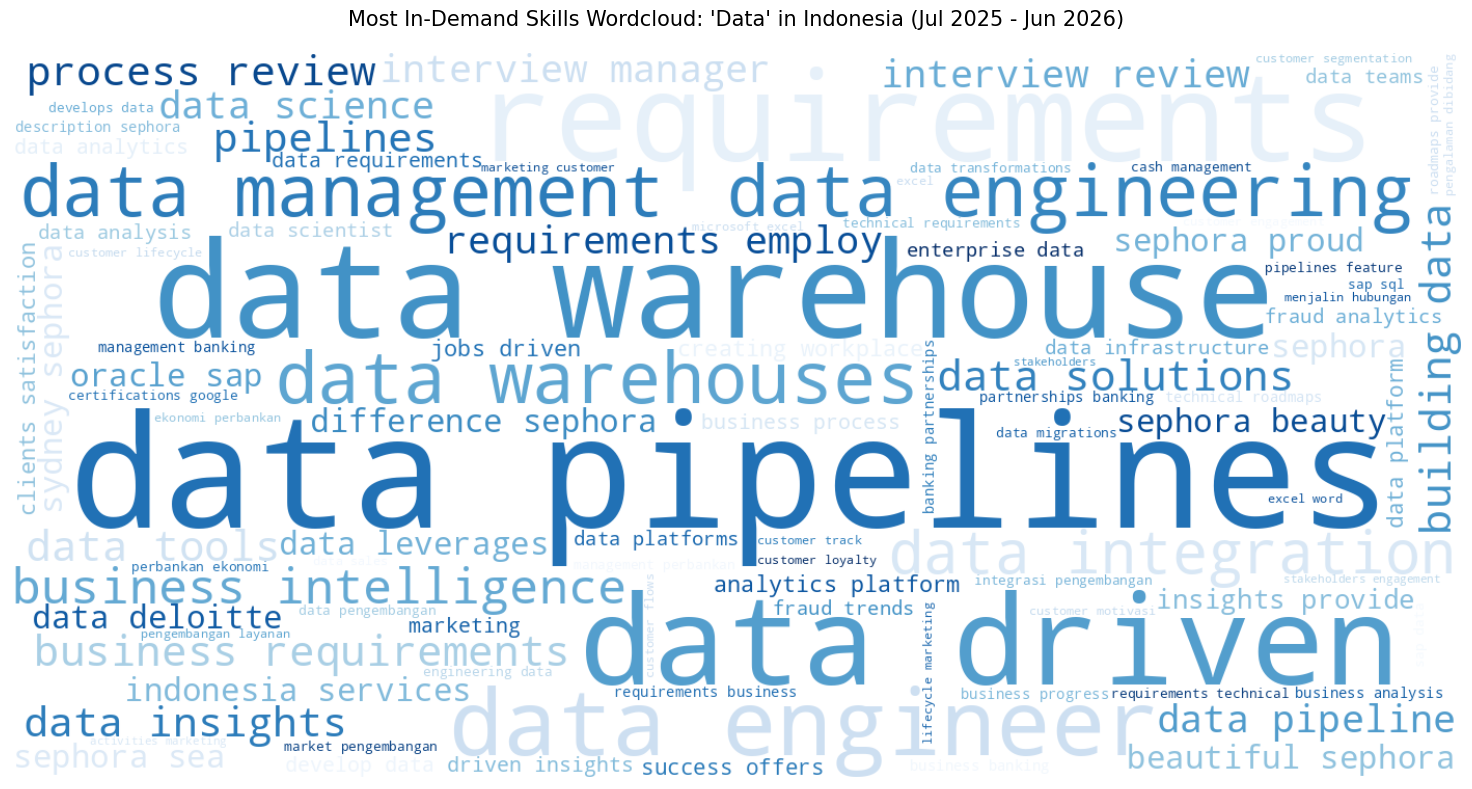

Wordcloud saved to dashboard/data/processed/wordcloud_skills.png


In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

skill_freq_dict = dict(Counter(all_skills_flat))

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Blues",
    max_words=100,
    collocations=False,
    prefer_horizontal=0.85
).generate_from_frequencies(skill_freq_dict)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    f"Most In-Demand Skills Wordcloud: '{job_query}' in {location_query} ({date_range_str})",
    fontsize=15,
    pad=20
)
plt.tight_layout()
os.makedirs("dashboard/data/processed", exist_ok=True)
plt.savefig("dashboard/data/processed/wordcloud_skills.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wordcloud saved to dashboard/data/processed/wordcloud_skills.png")

In [10]:
category_rows = []
for category in df_indonesia["job_category"].unique():
    category_df = df_indonesia[df_indonesia["job_category"] == category]
    flat_skills = [skill for skills_list in category_df["extracted_skills"] for skill in skills_list]
    top_5 = Counter(flat_skills).most_common(5)
    for skill, freq in top_5:
        category_rows.append({"job_category": category, "skill": skill, "frequency": freq})

df_category_skills = pd.DataFrame(category_rows)

df_heatmap = df_category_skills.pivot_table(
    index="skill",
    columns="job_category",
    values="frequency",
    fill_value=0
)

df_heatmap = df_heatmap.loc[df_heatmap.sum(axis=1).sort_values(ascending=False).index]

fig_category_skills = go.Figure(data=go.Heatmap(
    z=df_heatmap.values,
    x=df_heatmap.columns.tolist(),
    y=df_heatmap.index.tolist(),
    colorscale="teal",
    text=df_heatmap.values,
    texttemplate="%{text}",
    textfont={"size": 11},
    hoverongaps=False
))

fig_category_skills.update_layout(
    title=f"Top Skills by Job Category: '{job_query}' in {location_query}",
    xaxis_title="Job Category",
    yaxis_title="Skill",
    xaxis={"tickangle": -30},
    height=600,
    margin={"l": 180, "r": 40, "t": 80, "b": 120}
)
fig_category_skills.show()
print("Category skills dataframe shape:", df_category_skills.shape)

Category skills dataframe shape: (35, 3)


In [11]:
df_indonesia["posted_date"] = pd.to_datetime(df_indonesia["posted_date"], errors="coerce")
df_trend_base = df_indonesia.dropna(subset=["posted_date"]).copy()
df_trend_base["year_month"] = df_trend_base["posted_date"].dt.to_period("M").astype(str)

cutoff_month = (datetime.now() - timedelta(days=365)).strftime("%Y-%m")
df_trend = df_trend_base.groupby("year_month").size().reset_index(name="posting_count")
df_trend = df_trend.sort_values("year_month", ascending=True)
df_trend = df_trend[df_trend["year_month"] >= cutoff_month].reset_index(drop=True)

fig_trend = px.line(
    df_trend,
    x="year_month",
    y="posting_count",
    markers=True,
    title=f"Job Posting Volume Trend: '{job_query}' in {location_query}"
)
fig_trend.show()
print("Trend data shape:", df_trend.shape)

Trend data shape: (10, 2)


In [12]:
df_top_companies = (
    df_indonesia.groupby("company_name")
    .size()
    .reset_index(name="job_count")
    .sort_values("job_count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig_companies = px.bar(
    df_top_companies.sort_values("job_count", ascending=True),
    x="job_count",
    y="company_name",
    orientation="h",
    color="job_count",
    color_continuous_scale="Teal",
    title=f"Top 20 Companies Hiring for '{job_query}' in {location_query}"
)
fig_companies.show()
print(df_top_companies)

                                       company_name  job_count
0                                   PT. Indosat Tbk          5
1                        PT Astra International Tbk          4
2                                            Shopee          4
3                                            INFUSE          4
4                                    OCBC Indonesia          3
5                                            Blibli          2
6                                          Indodana          2
7                 PT Bank Digital BCA (BCA Digital)          2
8                                PT Lion Super Indo          2
9                      PT. Erajaya Swasembada, Tbk.          2
10                                         Deloitte          2
11                                        Amar Bank          2
12                      Philip Morris International          2
13                                          SEPHORA          2
14                                  FOOM LAB GLOBAL    

## 4.4 - 4.9 Additional Visualizations (Location, Category, Freshness, Remote, Salary, Trend Bar)

In [ ]:
# --- 4.4 Top Job Locations (City Distribution) ---
df_indonesia["city"] = df_indonesia["location"].apply(
    lambda x: str(x).split(",")[0].strip().title() if pd.notna(x) else "Unknown"
)

df_location_counts = (
    df_indonesia["city"]
    .value_counts()
    .head(15)
    .reset_index()
)
df_location_counts.columns = ["city", "count"]

fig_locations = px.bar(
    df_location_counts,
    x="city",
    y="count",
    color="count",
    color_continuous_scale="teal",
    title=f"Top Job Locations: '{job_query}' in {location_query}"
)
fig_locations.update_layout(
    xaxis_tickangle=-30,
    height=420,
    showlegend=False
)
fig_locations.show()
print(df_location_counts.head(10))

In [ ]:
# --- 4.5 Job Category Distribution (Pie/Donut) ---
df_category_counts = (
    df_indonesia["job_category"]
    .value_counts()
    .reset_index()
)
df_category_counts.columns = ["job_category", "count"]
df_category_counts["percentage"] = (
    df_category_counts["count"] / df_category_counts["count"].sum() * 100
).round(1)

fig_category_pie = px.pie(
    df_category_counts,
    names="job_category",
    values="count",
    hole=0.45,
    title=f"Job Category Distribution: '{job_query}' in {location_query}"
)
fig_category_pie.update_traces(
    textinfo="label+percent",
    textfont_size=11
)
fig_category_pie.update_layout(height=500)
fig_category_pie.show()
print(df_category_counts)

In [ ]:
# --- 4.6 Job Freshness (Age Distribution) ---
import numpy as np
from datetime import datetime, timedelta

now = pd.Timestamp.now()
df_fresh = df_indonesia.copy()
df_fresh["posted_date"] = pd.to_datetime(df_fresh["posted_date"], errors="coerce")
df_fresh["days_ago"] = (now - df_fresh["posted_date"]).dt.days

def classify_freshness(days):
    if pd.isna(days): return "Unknown"
    if days <= 7: return "Hot (<7d)"
    if days <= 14: return "Fresh (7-14d)"
    if days <= 30: return "Active (14-30d)"
    return "Aging (>30d)"

df_fresh["freshness"] = df_fresh["days_ago"].apply(classify_freshness)

freshness_order = ["Hot (<7d)", "Fresh (7-14d)", "Active (14-30d)", "Aging (>30d)", "Unknown"]
freshness_colors = ["#EF4444", "#F59E0B", "#10B981", "#94A3B8", "#CBD5E1"]
color_map = dict(zip(freshness_order, freshness_colors))

df_freshness_counts = (
    df_fresh["freshness"]
    .value_counts()
    .reindex(freshness_order, fill_value=0)
    .reset_index()
)
df_freshness_counts.columns = ["freshness", "count"]

# Gunakan text="count" langsung di px.bar() agar label per-bar benar.
# Tidak boleh pakai update_traces(text=array) saat color membuat multi-trace,
# karena array akan diapply ke setiap trace sekaligus dan label jadi salah.
fig_freshness = px.bar(
    df_freshness_counts,
    x="freshness",
    y="count",
    color="freshness",
    color_discrete_map=color_map,
    text="count",
    title=f"Job Freshness Distribution: '{job_query}' in {location_query}"
)
fig_freshness.update_layout(height=420, showlegend=False)
fig_freshness.update_traces(textposition="outside")
fig_freshness.show()
print(df_freshness_counts)

In [ ]:
# --- 4.7 Work Mode Distribution (Remote vs Onsite) ---
if "is_remote" in df_indonesia.columns:
    remote_map = {
        True: "Remote",
        False: "Onsite",
        "True": "Remote",
        "False": "Onsite",
    }
    df_remote = df_indonesia.copy()
    df_remote["work_mode"] = df_remote["is_remote"].map(remote_map).fillna("Tidak Diketahui")

    df_remote_counts = (
        df_remote["work_mode"]
        .value_counts()
        .reset_index()
    )
    df_remote_counts.columns = ["work_mode", "count"]

    fig_remote = px.pie(
        df_remote_counts,
        names="work_mode",
        values="count",
        hole=0.5,
        color="work_mode",
        color_discrete_map={"Remote": "#0D9488", "Onsite": "#0A66C2", "Tidak Diketahui": "#94A3B8"},
        title=f"Work Mode Distribution: '{job_query}' in {location_query}"
    )
    fig_remote.update_traces(textinfo="label+percent", textfont_size=12)
    fig_remote.update_layout(height=420)
    fig_remote.show()
    print(df_remote_counts)
else:
    print("Kolom 'is_remote' tidak tersedia di dataset ini.")

In [ ]:
# --- 4.8 Salary Distribution by Job Category ---
salary_cols = [c for c in ["min_amount", "max_amount"] if c in df_indonesia.columns]
if salary_cols:
    df_salary = df_indonesia.copy()
    if "min_amount" in df_salary.columns and "max_amount" in df_salary.columns:
        df_salary["avg_salary"] = df_salary[["min_amount", "max_amount"]].mean(axis=1)
    elif "min_amount" in df_salary.columns:
        df_salary["avg_salary"] = df_salary["min_amount"]
    else:
        df_salary["avg_salary"] = df_salary["max_amount"]

    df_salary_clean = df_salary.dropna(subset=["avg_salary"])
    pct_disclosed = round(len(df_salary_clean) / max(len(df_salary), 1) * 100, 1)
    print(f"Jobs dengan info gaji: {len(df_salary_clean)} ({pct_disclosed}% dari total)")

    if len(df_salary_clean) >= 5:
        df_salary_by_cat = (
            df_salary_clean
            .groupby("job_category")["avg_salary"]
            .agg(["mean", "median", "count"])
            .reset_index()
            .rename(columns={"mean": "avg", "median": "med", "count": "n"})
            .sort_values("avg", ascending=False)
        )
        df_salary_by_cat = df_salary_by_cat[df_salary_by_cat["n"] >= 2]

        cur = str(df_indonesia["currency"].dropna().iloc[0]) if "currency" in df_indonesia.columns and df_indonesia["currency"].notna().any() else "USD"

        fig_salary = px.bar(
            df_salary_by_cat,
            y="job_category",
            x="avg",
            orientation="h",
            color="avg",
            color_continuous_scale="Purples",
            text=df_salary_by_cat["avg"].apply(lambda v: f"{cur} {int(v):,}"),
            title=f"Avg Salary by Category: '{job_query}' in {location_query} ({cur})",
            custom_data=["n", "med"]
        )
        fig_salary.update_traces(
            textposition="outside",
            hovertemplate="<b>%{y}</b><br>Avg: %{text}<br>Median: %{customdata[1]:,.0f}<br>Sample: %{customdata[0]} jobs"
        )
        fig_salary.update_layout(
            height=max(350, len(df_salary_by_cat) * 50),
            yaxis={"categoryorder": "total ascending"},
            showlegend=False
        )
        fig_salary.show()
        print(df_salary_by_cat)

        fig_salary_box = px.box(
            df_salary_clean,
            x="job_category",
            y="avg_salary",
            color="job_category",
            points="outliers",
            title=f"Salary Distribution Box Plot: '{job_query}' ({cur})"
        )
        fig_salary_box.update_layout(height=480, xaxis_tickangle=-20, showlegend=False)
        fig_salary_box.show()
    else:
        print("Data gaji tidak cukup untuk visualisasi per kategori (min 5 records).")
else:
    print("Kolom salary (min_amount / max_amount) tidak tersedia di dataset ini.")
    print("Catatan: Salary info hanya tersedia untuk beberapa job platform.")

In [ ]:
# --- 4.9 Posting Trend (Bar Chart) - Alternatif visualisasi trend ---
fig_trend_bar = px.bar(
    df_trend,
    x="year_month",
    y="posting_count",
    color="posting_count",
    color_continuous_scale="teal",
    title=f"Job Posting Volume by Month (Bar): '{job_query}' in {location_query}"
)
fig_trend_bar.update_layout(
    xaxis_tickangle=-30,
    height=420,
    showlegend=False
)
fig_trend_bar.show()

# SECTION 5: INSTAGRAM DATA SCRAPING

In [13]:
def classify_content_topic(caption):
    cap = str(caption).lower()
    if "profil" in cap or "profile" in cap or "headline" in cap or "foto profil" in cap:
        return "Optimasi Profil LinkedIn"
    elif "personal brand" in cap or "branding" in cap:
        return "Personal Branding"
    elif "lamaran" in cap or "apply" in cap or "melamar" in cap or "cv" in cap or "resume" in cap or "portofolio" in cap:
        return "Tips Melamar Kerja"
    elif "skill" in cap or "kemampuan" in cap or "kompetensi" in cap:
        return "Skill dan Kompetensi"
    elif "interview" in cap or "wawancara" in cap:
        return "Persiapan Interview"
    elif "networking" in cap or "koneksi" in cap or "connect" in cap or "relasi" in cap:
        return "Networking LinkedIn"
    elif "fresh graduate" in cap or "mahasiswa" in cap or "kampus" in cap or "wisuda" in cap:
        return "Konten untuk Mahasiswa"
    elif "karir" in cap or "career" in cap or "pekerjaan" in cap or "kerja" in cap or "job" in cap:
        return "Pengembangan Karir"
    elif "tips" in cap or "cara" in cap or "panduan" in cap or "langkah" in cap:
        return "Tips dan Panduan Umum"
    else:
        return "Konten Lainnya"

def extract_hashtags(caption):
    return [tag.lower() for tag in re.findall(r"#(\w+)", str(caption))]

print("Helper functions defined.")

Helper functions defined.


In [14]:
import requests

CACHE_PATH = "dashboard/data/raw/instagram_posts.csv"
CACHE_META_PATH = "dashboard/data/raw/instagram_cache_meta.json"
CACHE_EXPIRY_DAYS = 30

def is_cache_valid():
    if not os.path.exists(CACHE_PATH) or not os.path.exists(CACHE_META_PATH):
        return False
    with open(CACHE_META_PATH, "r") as f:
        meta = json.load(f)
    cached_time = meta.get("cached_at", 0)
    age_days = (time.time() - cached_time) / 86400
    print(f"Cache umur: {age_days:.1f} hari (expiry: {CACHE_EXPIRY_DAYS} hari)")
    return age_days < CACHE_EXPIRY_DAYS

def save_cache_meta():
    os.makedirs("dashboard/data/raw", exist_ok=True)
    with open(CACHE_META_PATH, "w") as f:
        json.dump({
            "cached_at": time.time(),
            "cached_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "ig_username": ig_username,
            "expires_on": (datetime.now() + timedelta(days=CACHE_EXPIRY_DAYS)).strftime("%Y-%m-%d")
        }, f, indent=2)

def delete_cache():
    if os.path.exists(CACHE_PATH):
        os.remove(CACHE_PATH)
    if os.path.exists(CACHE_META_PATH):
        os.remove(CACHE_META_PATH)
    print("Cache lama dihapus, akan scrape ulang.")

if is_cache_valid():
    df_content = pd.read_csv(CACHE_PATH)
    print(f"Cached Instagram data loaded ({len(df_content)} posts).")
else:
    delete_cache()
    try:
        from getpass import getpass

        if "APIFY_TOKEN" not in os.environ:
            os.environ["APIFY_TOKEN"] = getpass("Masukkan Apify API Token: ")
        APIFY_TOKEN = os.environ["APIFY_TOKEN"]
        ig_username = "belajarlinkedin"

        print(f"Menjalankan Apify scraper untuk @{ig_username}...")

        run_url = f"https://api.apify.com/v2/acts/apify~instagram-scraper/runs?token={APIFY_TOKEN}"
        payload = {
            "directUrls": [f"https://www.instagram.com/{ig_username}/"],
            "resultsType": "posts",
            "resultsLimit": 150,
            "addParentData": True
        }

        run_response = requests.post(run_url, json=payload)
        run_data = run_response.json()

        if "data" not in run_data:
            raise RuntimeError(f"Gagal menjalankan Apify actor: {run_data}")

        run_id = run_data["data"]["id"]
        print(f"Apify run started. Run ID: {run_id}")

        while True:
            status_resp = requests.get(
                f"https://api.apify.com/v2/actor-runs/{run_id}?token={APIFY_TOKEN}"
            ).json()
            status = status_resp["data"]["status"]
            print(f"Status: {status}")
            if status in ["SUCCEEDED", "FAILED", "ABORTED", "TIMED-OUT"]:
                break
            time.sleep(10)

        if status != "SUCCEEDED":
            raise RuntimeError(f"Apify run gagal dengan status: {status}")

        dataset_id = status_resp["data"]["defaultDatasetId"]
        items = requests.get(
            f"https://api.apify.com/v2/datasets/{dataset_id}/items?token={APIFY_TOKEN}&format=json"
        ).json()

        if not items:
            raise RuntimeError("Apify berhasil jalan tapi tidak ada data.")

        print(f"Total raw items dari Apify: {len(items)}")

        follower_count = items[0].get("followersCount", 0) if items else 0

        posts_data = []
        for post in items:
            caption_text = post.get("caption", "") or ""
            raw_type = str(
                post.get("type") or
                post.get("__typename") or
                post.get("productType") or ""
            ).lower()

            if any(kw in raw_type for kw in ["sidecar", "carousel", "album", "multi"]):
                post_type = "Carousel"
            elif any(kw in raw_type for kw in ["video", "reel", "igtv", "clip"]):
                post_type = "Video"
            elif any(kw in raw_type for kw in ["image", "photo", "picture"]):
                post_type = "Image"
            else:
                post_type = "Other"

            post_record = {
                "post_date": (post.get("timestamp") or post.get("taken_at_timestamp") or "")[:10],
                "post_type": post_type,
                "caption": caption_text,
                "likes": post.get("likesCount") or post.get("edge_media_preview_like", {}).get("count", 0) or 0,
                "comments": post.get("commentsCount") or post.get("edge_media_to_comment", {}).get("count", 0) or 0,
                "hashtags": extract_hashtags(caption_text),
                "video_views": post.get("videoViewCount") or post.get("video_view_count") or 0,
                "shortcode": post.get("shortCode") or post.get("shortcode") or ""
            }
            posts_data.append(post_record)

        if not posts_data:
            raise RuntimeError("Tidak ada post yang berhasil di-parse.")

        df_content = pd.DataFrame(posts_data)
        df_content["engagement_total"] = df_content["likes"] + df_content["comments"]
        df_content["engagement_rate"] = (
            (df_content["engagement_total"] / follower_count * 100).round(4)
            if follower_count > 0 else 0
        )
        df_content["post_topic"] = df_content["caption"].apply(classify_content_topic)
        df_content["follower_count"] = int(follower_count)
        df_content["ig_username"] = ig_username

        os.makedirs("dashboard/data/raw", exist_ok=True)
        df_content.to_csv(CACHE_PATH, index=False)
        save_cache_meta()
        print(f"Berhasil scrape {len(df_content)} posts dari @{ig_username}.")

    except Exception as exc:
        print(f"Scraping exception: {exc}")
        raise RuntimeError("Scraping gagal dan tidak ada cached data valid.")

Cache lama dihapus, akan scrape ulang.
Masukkan Apify API Token: ··········
Menjalankan Apify scraper untuk @belajarlinkedin...
Apify run started. Run ID: C4pYTisIXhLDoGHRY
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: SUCCEEDED
Total raw items dari Apify: 33
Berhasil scrape 33 posts dari @belajarlinkedin.


In [15]:
df_content["post_date"] = pd.to_datetime(df_content["post_date"], errors="coerce")
df_content = df_content.sort_values("post_date", ascending=False).reset_index(drop=True)

print("df_content shape:", df_content.shape)
print(df_content)
print("\nPost type distribution:")
print(df_content["post_type"].value_counts())
print("\nPost topic distribution:")
print(df_content["post_topic"].value_counts())
print("\nDate range:", df_content["post_date"].min(), "to", df_content["post_date"].max())
print("\nEngagement stats:")
print(df_content[["likes", "comments", "engagement_rate"]].describe())

df_content shape: (33, 13)
    post_date post_type                                            caption  \
0  2026-06-02  Carousel  🚀 [OPEN REGISTRATION] Kickstart Your Career Jo...   
1  2025-11-08  Carousel  🌱 Di balik performa hebat, ada mental yang kua...   
2  2025-11-01  Carousel  Budaya kerja modern sering memuja lelah dan me...   
3  2025-10-31  Carousel  Nunggu siap? Itu perangkap otak.\nKarena otakm...   
4  2025-10-30  Carousel  Punya career break bukan berarti kariermu rusa...   
5  2025-10-26  Carousel  Jangan iri sama orang yang punya 10.000 koneks...   
6  2025-10-24  Carousel  Scroll LinkedIn sebentar aja, rasanya semua or...   
7  2025-10-23  Carousel  Katanya susah dapet view & DM di LinkedIn?\n\n...   
8  2025-10-22  Carousel  Udah isi profil LinkedIn sebaik mungkin, tapi ...   
9  2025-10-21  Carousel  Berani Pindah, Bukan Berarti Tak Setia\n\nLoya...   
10 2025-09-23  Carousel  Buka LinkedIn, bukannya semangat malah jadi in...   
11 2025-09-22  Carousel  Job posting 

# SECTION 6: CONTENT PERFORMANCE ANALYSIS

In [16]:
df_type_performance = (
    df_content.groupby("post_type")
    .agg(
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        total_likes=("likes", "sum"),
        total_comments=("comments", "sum"),
        post_count=("shortcode", "count"),
        max_engagement_rate=("engagement_rate", "max"),
        min_engagement_rate=("engagement_rate", "min"),
    )
    .reset_index()
)
df_type_performance["avg_engagement_rate"] = df_type_performance["avg_engagement_rate"].round(2)
df_type_performance["median_engagement_rate"] = df_type_performance["median_engagement_rate"].round(2)
df_type_performance["avg_likes"] = df_type_performance["avg_likes"].round(0)
df_type_performance["avg_comments"] = df_type_performance["avg_comments"].round(0)
df_type_performance["engagement_per_post_share"] = (
    df_type_performance["post_count"] / df_type_performance["post_count"].sum() * 100
).round(1)

ig_username_label = df_content["ig_username"].iloc[0] if "ig_username" in df_content.columns else "Instagram"

fig_engagement_type = px.bar(
    df_type_performance.sort_values("avg_engagement_rate", ascending=False),
    x="post_type",
    y="avg_engagement_rate",
    color="post_type",
    text="avg_engagement_rate",
    error_y=df_type_performance.sort_values("avg_engagement_rate", ascending=False)["max_engagement_rate"] -
            df_type_performance.sort_values("avg_engagement_rate", ascending=False)["avg_engagement_rate"],
    error_y_minus=df_type_performance.sort_values("avg_engagement_rate", ascending=False)["avg_engagement_rate"] -
                  df_type_performance.sort_values("avg_engagement_rate", ascending=False)["min_engagement_rate"],
    title=f"Average Engagement Rate by Content Type — @{ig_username_label}",
    labels={"avg_engagement_rate": "Avg Engagement Rate (%)", "post_type": "Content Type"},
)
fig_engagement_type.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig_engagement_type.update_layout(showlegend=False)
fig_engagement_type.show()

print("\nContent Type Performance Summary:")
print(df_type_performance.to_string(index=False))


Content Type Performance Summary:
post_type  avg_engagement_rate  median_engagement_rate  avg_likes  avg_comments  total_likes  total_comments  post_count  max_engagement_rate  min_engagement_rate  engagement_per_post_share
 Carousel                26.93                   30.05     1798.0          48.0        57546            1542          32              81.4177              -0.0146                       97.0
    Image                33.55                   33.55     2300.0           0.0         2300               0           1              33.5473              33.5473                        3.0


In [17]:
df_likes_comments = df_type_performance.melt(
    id_vars="post_type",
    value_vars=["avg_likes", "avg_comments"],
    var_name="metric",
    value_name="value"
)
df_likes_comments["metric"] = df_likes_comments["metric"].map({
    "avg_likes": "Avg Likes",
    "avg_comments": "Avg Comments"
})

fig_likes_comments = px.bar(
    df_likes_comments,
    x="post_type",
    y="value",
    color="metric",
    barmode="stack",
    text="value",
    title=f"Avg Likes vs Comments Breakdown by Content Type — @{ig_username_label}",
    labels={"value": "Count", "post_type": "Content Type", "metric": "Metric"},
    color_discrete_map={"Avg Likes": "#4C78A8", "Avg Comments": "#F58518"}
)
fig_likes_comments.update_traces(texttemplate="%{text:.0f}", textposition="inside")
fig_likes_comments.show()

In [18]:
fig_volume = px.pie(
    df_type_performance,
    names="post_type",
    values="post_count",
    title=f"Post Volume Distribution by Content Type — @{ig_username_label}",
    hole=0.4
)
fig_volume.update_traces(texttemplate="%{label}<br>%{value} posts<br>(%{percent})")
fig_volume.show()

In [19]:
if len(df_content) >= 5:
    fig_box = px.box(
        df_content,
        x="post_type",
        y="engagement_rate",
        color="post_type",
        points="all",
        title=f"Engagement Rate Distribution by Content Type — @{ig_username_label}",
        labels={"engagement_rate": "Engagement Rate (%)", "post_type": "Content Type"},
    )
    fig_box.update_layout(showlegend=False)
    fig_box.show()
else:
    print("Box plot dilewati: data terlalu sedikit untuk distribusi yang informatif.")

In [20]:
df_topic_performance = (
    df_content.groupby("post_topic")
    .agg(
        engagement_rate=("engagement_rate", "mean"),
        likes=("likes", "sum"),
        comments=("comments", "sum"),
        post_count=("shortcode", "count")
    )
    .reset_index()
    .sort_values("engagement_rate", ascending=False)
    .reset_index(drop=True)
)

fig_topic_perf = px.bar(
    df_topic_performance.sort_values("engagement_rate", ascending=True),
    y="post_topic",
    x="engagement_rate",
    color="engagement_rate",
    color_continuous_scale="viridis_r",
    orientation="h",
    title="Content Topic Performance Ranking by Engagement Rate"
)
fig_topic_perf.update_layout(yaxis={"categoryorder": "total ascending"})
fig_topic_perf.show()
print(df_topic_performance)

                 post_topic  engagement_rate  likes  comments  post_count
0        Tips Melamar Kerja        64.213800   7266      1539           2
1     Tips dan Panduan Umum        38.666900   5302         0           2
2        Pengembangan Karir        31.425050   4309         0           2
3  Optimasi Profil LinkedIn        28.947275  15876         1           8
4      Skill dan Kompetensi        28.427700   1949         0           1
5         Personal Branding        24.473582  18455         2          11
6       Networking LinkedIn        21.577200   4438         0           3
7            Konten Lainnya         8.208125   2251         0           4


In [21]:
df_content["post_date"] = pd.to_datetime(df_content["post_date"])
df_content["day_of_week"] = df_content["post_date"].dt.day_name()
df_content["month_year"] = df_content["post_date"].dt.to_period("M").astype(str)
df_content["hour_of_day"] = df_content["post_date"].dt.hour

df_day_pattern = df_content.groupby("day_of_week")["engagement_rate"].mean()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_day_pattern = df_day_pattern.reindex(day_order)

fig_day_pattern = px.bar(
    df_day_pattern.reset_index(),
    x="day_of_week",
    y="engagement_rate",
    title="Best Day to Post on BelajarLinkedIn by Engagement Rate"
)
fig_day_pattern.show()

In [22]:
df_monthly_trend = (
    df_content.groupby("month_year")
    .agg(
        engagement_rate=("engagement_rate", "mean"),
        post_count=("shortcode", "count")
    )
    .reset_index()
    .sort_values("month_year", ascending=True)
)

fig_monthly_trend = px.line(
    df_monthly_trend,
    x="month_year",
    y="engagement_rate",
    title="Monthly Engagement Rate Trend on BelajarLinkedIn Instagram",
    markers=True
)
fig_monthly_trend.show()

In [23]:
df_hashtag_exploded = df_content.copy()

if df_hashtag_exploded["hashtags"].dtype == object:
    df_hashtag_exploded["hashtags"] = df_hashtag_exploded["hashtags"].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.startswith("[") else (x if isinstance(x, list) else [])
    )

df_hashtag_exploded = df_hashtag_exploded.explode("hashtags")
df_hashtag_exploded = df_hashtag_exploded[df_hashtag_exploded["hashtags"].notna() & (df_hashtag_exploded["hashtags"] != "")]

top_hashtags = Counter(df_hashtag_exploded["hashtags"].tolist()).most_common(20)
df_hashtag_freq = pd.DataFrame(top_hashtags, columns=["hashtag", "frequency"])

fig_hashtag = px.bar(
    df_hashtag_freq,
    x="hashtag",
    y="frequency",
    title="Top 20 Hashtags Used by BelajarLinkedIn"
)

fig_hashtag.show()
print(df_hashtag_freq)

               hashtag  frequency
0      belajarlinkedin         25
1     personalbranding         12
2     linkedinstrategy          9
3         linkedintips          8
4       growonlinkedin          8
5    nextlevellinkedin          8
6    linkedinindonesia          7
7    contentpsychology          6
8         careergrowth          4
9           careertips          3
10  linkedinnetworking          3
11  networkingstrategy          3
12          networking          2
13        tipslinkedin          2
14     mindcaresession          1
15    employeebranding          1
16  workplacewellbeing          1
17  mentalhealthatwork          1
18  employeeengagement          1
19     worklifebalance          1


# SECTION 7: GAP ANALYSIS ENGINE

In [24]:
CAREER_THEMES = {
    "Skill Teknis & Tools": [
        "sql", "python", "excel", "tableau", "analytics", "software",
        "coding", "programming", "technical skill", "microsoft office",
        "power bi", "google analytics", "machine learning", "data analysis"
    ],
    "Soft Skills & Komunikasi": [
        "communication", "interpersonal", "presentation", "writing",
        "verbal", "collaboration", "teamwork", "negotiation",
        "public speaking", "komunikasi", "kerjasama"
    ],
    "Leadership & Management": [
        "leadership", "management", "team lead", "supervisor", "managerial",
        "coordinate", "strategic", "decision making", "people management",
        "kepemimpinan", "manajerial"
    ],
    "Networking & Relationship": [
        "networking", "stakeholder", "relationship", "client management",
        "partnership", "liaison", "cross functional", "build relationship"
    ],
    "Pengembangan Karir": [
        "career growth", "career development", "upskill", "training",
        "certification", "professional development", "continuous learning",
        "karir", "pengembangan diri"
    ],
    "Persiapan Interview & Lamaran": [
        "interview", "resume", "cv", "portfolio", "cover letter",
        "hiring process", "recruitment", "lamaran", "wawancara"
    ],
    "Personal Branding & LinkedIn": [
        "personal brand", "linkedin", "profile", "visibility",
        "professional presence", "thought leader", "online presence",
        "branding", "profil linkedin"
    ],
    "Problem Solving & Analytical": [
        "problem solving", "analytical thinking", "critical thinking",
        "data driven", "troubleshoot", "solution oriented"
    ],
    "Work Culture & Adaptability": [
        "adaptable", "fast paced", "agile", "flexible", "remote work",
        "hybrid", "self motivated", "proactive", "initiative"
    ],
    "Industry Knowledge": [
        "industry knowledge", "market understanding", "business acumen",
        "domain knowledge", "business process", "industry trend"
    ]
}

TOPIC_TO_THEME = {
    "Optimasi Profil LinkedIn": "Personal Branding & LinkedIn",
    "Personal Branding": "Personal Branding & LinkedIn",
    "Tips Melamar Kerja": "Persiapan Interview & Lamaran",
    "Skill dan Kompetensi": "Skill Teknis & Tools",
    "Persiapan Interview": "Persiapan Interview & Lamaran",
    "Networking LinkedIn": "Networking & Relationship",
    "Konten untuk Mahasiswa": "Pengembangan Karir",
    "Pengembangan Karir": "Pengembangan Karir",
    "Tips dan Panduan Umum": "Soft Skills & Komunikasi",
    "Konten Lainnya": None
}

text_col = "cleaned_description" if "cleaned_description" in df_indonesia.columns else "description"
all_descriptions = df_indonesia[text_col].fillna("").str.lower().tolist()
total_jobs = len(all_descriptions)

theme_market_freq = {}
theme_top_keywords = {}
for theme, keywords in CAREER_THEMES.items():
    match_count = sum(1 for desc in all_descriptions if any(kw in desc for kw in keywords))
    theme_market_freq[theme] = match_count / total_jobs if total_jobs > 0 else 0

    kw_counts = {kw: sum(1 for desc in all_descriptions if kw in desc) for kw in keywords}
    top_kws = sorted(kw_counts.items(), key=lambda x: x[1], reverse=True)[:3]
    theme_top_keywords[theme] = [kw for kw, count in top_kws if count > 0]

theme_posts_count = {theme: 0 for theme in CAREER_THEMES}
theme_engagement_list = {theme: [] for theme in CAREER_THEMES}

for _, row in df_content.iterrows():
    mapped = TOPIC_TO_THEME.get(row.get("post_topic", ""))
    if mapped and mapped in theme_posts_count:
        theme_posts_count[mapped] += 1
        er = row.get("engagement_rate", 0)
        if pd.notna(er):
            theme_engagement_list[mapped].append(float(er))

total_posts = len(df_content)

gap_rows = []
for theme in CAREER_THEMES:
    market_freq = theme_market_freq[theme]
    posts_count = theme_posts_count[theme]
    coverage_rate = posts_count / total_posts if total_posts > 0 else 0
    avg_er = round(np.mean(theme_engagement_list[theme]), 2) if theme_engagement_list[theme] else 0
    gap_score = market_freq * (1 - min(coverage_rate * 3, 1))

    gap_rows.append({
        "content_topic": theme,
        "market_frequency": round(market_freq, 3),
        "posts_count": posts_count,
        "coverage_rate": round(coverage_rate, 3),
        "avg_engagement_rate": avg_er,
        "top_keywords_in_jobs": theme_top_keywords.get(theme, []),
        "gap_score": round(gap_score, 3),
        "opportunity_score": round(gap_score * 100, 2)
    })

df_gap = pd.DataFrame(gap_rows).sort_values("opportunity_score", ascending=False).reset_index(drop=True)

print("Gap Analysis Results:")
print(df_gap[["content_topic", "market_frequency", "posts_count", "coverage_rate", "opportunity_score"]].to_string(index=False))

Gap Analysis Results:
                content_topic  market_frequency  posts_count  coverage_rate  opportunity_score
         Skill Teknis & Tools             0.845            1          0.030              76.84
      Leadership & Management             0.667            0          0.000              66.67
 Problem Solving & Analytical             0.476            0          0.000              47.62
    Networking & Relationship             0.476            3          0.091              34.63
     Soft Skills & Komunikasi             0.405            2          0.061              33.12
  Work Culture & Adaptability             0.286            0          0.000              28.57
Persiapan Interview & Lamaran             0.250            2          0.061              20.45
           Pengembangan Karir             0.214            2          0.061              17.53
           Industry Knowledge             0.131            0          0.000              13.10
 Personal Branding & LinkedI

In [25]:
fig_gap_scatter = px.scatter(
    df_gap,
    x="coverage_rate",
    y="market_frequency",
    text="content_topic",
    color="opportunity_score",
    size="opportunity_score",
    color_continuous_scale="RdYlGn_r",
    title=f"Content Gap: Market Demand vs Instagram Coverage — '{job_query}' in {location_query}",
    labels={
        "coverage_rate": "Coverage di Konten @belajarlinkedin",
        "market_frequency": "Frekuensi Muncul di Job Postings"
    }
)
fig_gap_scatter.add_vline(x=df_gap["coverage_rate"].median(), line_dash="dash", line_color="gray")
fig_gap_scatter.add_hline(y=df_gap["market_frequency"].median(), line_dash="dash", line_color="gray")
fig_gap_scatter.update_traces(textposition="top center")
fig_gap_scatter.show()

fig_opportunity = px.bar(
    df_gap.sort_values("opportunity_score", ascending=True),
    y="content_topic",
    x="opportunity_score",
    color="opportunity_score",
    color_continuous_scale="Reds",
    orientation="h",
    title="Content Opportunity Score by Theme"
)
fig_opportunity.update_layout(yaxis={"categoryorder": "total ascending"})
fig_opportunity.show()

fig_market_vs_coverage = px.bar(
    df_gap.melt(
        id_vars="content_topic",
        value_vars=["market_frequency", "coverage_rate"],
        var_name="metric",
        value_name="value"
    ),
    x="content_topic",
    y="value",
    color="metric",
    barmode="group",
    title=f"Market Demand vs Instagram Coverage per Theme — @{ig_username_label}",
    labels={"content_topic": "Tema", "value": "Rate", "metric": "Metric"},
    color_discrete_map={"market_frequency": "#EF553B", "coverage_rate": "#636EFA"}
)
fig_market_vs_coverage.update_layout(xaxis_tickangle=-30)
fig_market_vs_coverage.show()

In [ ]:
# --- 7.2 Gap Analysis - Opportunity Score Bar Chart ---
df_gap_sorted = df_gap.sort_values("opportunity_score", ascending=False).head(15).reset_index(drop=True)

fig_gap_bar = px.bar(
    df_gap_sorted,
    y="content_topic",
    x="opportunity_score",
    orientation="h",
    color="opportunity_score",
    color_continuous_scale="RdYlGn",
    text=df_gap_sorted["opportunity_score"].round(1),
    title="Top 15 Content Opportunities - Opportunity Score Ranking"
)
fig_gap_bar.update_traces(textposition="outside")
fig_gap_bar.update_layout(
    height=550,
    yaxis={"categoryorder": "total ascending"},
    showlegend=False,
    xaxis_title="Opportunity Score",
    yaxis_title="Content Topic"
)
fig_gap_bar.show()
print(df_gap_sorted[["content_topic", "opportunity_score", "market_frequency", "coverage_rate"]].to_string(index=False))

# SECTION 8: CONTENT RECOMMENDATION ENGINE

In [26]:
top5_gaps = df_gap.head(5).reset_index(drop=True)

best_format_row = df_type_performance.loc[df_type_performance["avg_engagement_rate"].idxmax()]
best_format = str(best_format_row["post_type"])
best_format_er = round(float(best_format_row["avg_engagement_rate"]), 2)
overall_avg_er = round(float(df_content["engagement_rate"].mean()), 2)

print("-" * 60)
print("       CONTENT RECOMMENDATION - TOP 5 OPPORTUNITIES")
print("-" * 60)

recommendations_list = []
for idx, row in top5_gaps.iterrows():
    opp_score = float(row["opportunity_score"])
    market_freq = float(row["market_frequency"])
    coverage = float(row["coverage_rate"])
    posts_count = int(row["posts_count"])
    avg_er = float(row["avg_engagement_rate"])
    top_kws = row.get("top_keywords_in_jobs", [])

    if opp_score > 60:
        freq = "3x per week"
    elif opp_score > 30:
        freq = "2x per week"
    else:
        freq = "1x per week"

    reasoning_parts = []

    reasoning_parts.append(
        f"{round(market_freq * 100, 1)}% job posting '{job_query}' di {location_query} "
        f"menyebut tema ini, artinya ini yang dicari employer dari kandidat."
    )

    if posts_count == 0:
        reasoning_parts.append(
            f"@{ig_username_label} belum pernah membuat konten tentang ini "
            f"dari total {total_posts} post yang ada."
        )
    elif coverage < 0.2:
        reasoning_parts.append(
            f"Baru {posts_count} post yang menyentuh tema ini - "
            f"sangat kurang dibanding tingginya kebutuhan di job market."
        )
    else:
        reasoning_parts.append(
            f"Sudah ada {posts_count} post, namun belum sebanding dengan "
            f"demand job market di angka {round(market_freq * 100, 1)}%."
        )

    if top_kws:
        reasoning_parts.append(
            f"Keyword paling sering di job posting: {', '.join(top_kws)}."
        )

    if avg_er > 0:
        comparison = "di atas" if avg_er > overall_avg_er else "di bawah"
        reasoning_parts.append(
            f"Post yang sudah ada di tema ini rata-rata {avg_er}% engagement rate "
            f"({comparison} rata-rata akun {overall_avg_er}%)."
        )

    reasoning = " ".join(reasoning_parts)

    recommendations_list.append({
        "rank": idx + 1,
        "content_topic": row["content_topic"],
        "opportunity_score": opp_score,
        "market_frequency_pct": f"{round(market_freq * 100, 1)}%",
        "posts_count": posts_count,
        "coverage_rate": coverage,
        "avg_engagement_rate": avg_er,
        "top_keywords": ", ".join(top_kws) if top_kws else "-",
        "recommended_format": best_format,
        "recommended_frequency": freq,
        "reasoning": reasoning
    })

    print(f"\n[{idx+1}] {row['content_topic']}")
    print(f"     Opportunity  : {opp_score:.2f} | Market Demand: {round(market_freq*100,1)}% | Posts Ada: {posts_count}")
    print(f"     Keywords     : {', '.join(top_kws) if top_kws else '-'}")
    print(f"     Format       : {best_format} ({best_format_er}% avg ER) | Frekuensi: {freq}")
    print(f"     Insight      : {reasoning}")

df_recommendations = pd.DataFrame(recommendations_list)

print("\n\nFINAL RECOMMENDATIONS")
print("-" * 95)
print(df_recommendations[[
    "rank", "content_topic", "opportunity_score",
    "recommended_format", "recommended_frequency"
]].to_string(index=False))

top_topic = df_recommendations.iloc[0]["content_topic"]
top_score = df_recommendations.iloc[0]["opportunity_score"]
print(f"\nTop recommended topic: {top_topic} (opportunity score: {top_score})")

------------------------------------------------------------
       CONTENT RECOMMENDATION - TOP 5 OPPORTUNITIES
------------------------------------------------------------

[1] Skill Teknis & Tools
     Opportunity  : 76.84 | Market Demand: 84.5% | Posts Ada: 1
     Keywords     : sql, python, analytics
     Format       : Image (33.55% avg ER) | Frekuensi: 3x per week
     Insight      : 84.5% job posting 'Data' di Indonesia menyebut tema ini, artinya ini yang dicari employer dari kandidat. Baru 1 post yang menyentuh tema ini - sangat kurang dibanding tingginya kebutuhan di job market. Keyword paling sering di job posting: sql, python, analytics. Post yang sudah ada di tema ini rata-rata 28.43% engagement rate (di atas rata-rata akun 27.13%).

[2] Leadership & Management
     Opportunity  : 66.67 | Market Demand: 66.7% | Posts Ada: 0
     Keywords     : management, decision making, leadership
     Format       : Image (33.55% avg ER) | Frekuensi: 3x per week
     Insight      : 66.7

# SECTION 9: SAVE OUTPUTS FOR DASHBOARD

In [27]:
os.makedirs("dashboard/data/processed", exist_ok=True)

df_skill_frequency.to_csv("dashboard/data/processed/skill_frequency.csv", index=False)
df_category_skills.to_csv("dashboard/data/processed/category_skills.csv", index=False)
df_top_companies.to_csv("dashboard/data/processed/top_companies.csv", index=False)
df_content.to_csv("dashboard/data/processed/content_performance.csv", index=False)
df_type_performance.to_csv("dashboard/data/processed/type_performance.csv", index=False)
df_topic_performance.to_csv("dashboard/data/processed/topic_performance.csv", index=False)
df_day_pattern.reset_index().to_csv("dashboard/data/processed/day_pattern.csv", index=False)
df_monthly_trend.to_csv("dashboard/data/processed/monthly_trend.csv", index=False)
df_hashtag_freq.to_csv("dashboard/data/processed/hashtag_freq.csv", index=False)
df_gap.to_csv("dashboard/data/processed/gap_analysis.csv", index=False)
df_recommendations.to_csv("dashboard/data/processed/recommendations.csv", index=False)
df_indonesia.to_csv("dashboard/data/processed/df_indonesia.csv", index=False)

if "df_trend" in dir() and df_trend is not None and len(df_trend) > 0:
    df_trend.to_csv("dashboard/data/processed/posting_trend.csv", index=False)
    print("posting_trend.csv saved.")
else:
    print("posting_trend.csv dilewati: data tidak cukup.")

print("All CSV files saved to dashboard/data/processed/")

def safe_fig_json(fig):
    try:
        return fig.to_json() if fig is not None else None
    except Exception:
        return None

all_figures_dict = {
    "skill_bar": safe_fig_json(fig_skill_bar),
    "category_skills": safe_fig_json(fig_category_skills),
    "companies": safe_fig_json(fig_companies),
    "engagement_type": safe_fig_json(fig_engagement_type),
    "likes_comments": safe_fig_json(fig_likes_comments),
    "post_type_volume": safe_fig_json(fig_volume),
    "topic_perf": safe_fig_json(fig_topic_perf),
    "day_pattern": safe_fig_json(fig_day_pattern),
    "monthly_trend": safe_fig_json(fig_monthly_trend),
    "hashtag": safe_fig_json(fig_hashtag),
    "gap_scatter": safe_fig_json(fig_gap_scatter),
    "opportunity": safe_fig_json(fig_opportunity),
    "market_vs_coverage": safe_fig_json(fig_market_vs_coverage),
    "trend": safe_fig_json(fig_trend) if "fig_trend" in dir() else None,
    "box_engagement": safe_fig_json(fig_box) if "fig_box" in dir() else None,
}

all_figures_dict = {k: v for k, v in all_figures_dict.items() if v is not None}

with open("dashboard/data/processed/all_figures.json", "w", encoding="utf-8") as f:
    json.dump(all_figures_dict, f, indent=2, ensure_ascii=False)

metadata = {
    "job_query": job_query,
    "location_query": location_query,
    "ig_username": ig_username_label,
    "total_jobs": len(df_jobs),
    "total_indonesia": len(df_indonesia),
    "total_ig_posts": len(df_content),
    "date_range": date_range_str,
    "run_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "figures_saved": list(all_figures_dict.keys())
}

with open("dashboard/data/processed/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\nAll outputs saved to dashboard/data/processed/:")
print(f"  JSON : all_figures.json ({len(all_figures_dict)} figures), metadata.json")
print(f"\nMetadata:")
for k, v in metadata.items():
    if k != "figures_saved":
        print(f"  {k}: {v}")

posting_trend.csv saved.
All CSV files saved to dashboard/data/processed/

All outputs saved to dashboard/data/processed/:
  JSON : all_figures.json (15 figures), metadata.json

Metadata:
  job_query: Data
  location_query: Indonesia
  ig_username: belajarlinkedin
  total_jobs: 86
  total_indonesia: 84
  total_ig_posts: 33
  date_range: Jul 2025 - Jun 2026
  run_timestamp: 2026-06-23 22:52:33


In [29]:
from google.colab import files
import shutil

folder_path = "/content/dashboard/data"
zip_path = "/content/dashboard_data.zip"
shutil.make_archive(zip_path.replace(".zip", ""), "zip", folder_path)
files.download(zip_path)
print("Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!
